[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/notebook.ipynb)

# 51 Pegasi b: the parameters of the first exoplanet found around a sun-like star

51 Pegasi b was the first exoplanet ever confirmed around a normal, sun-like star (in 1995), found using the radial velocity method -- watching the star's own light wobble in wavelength as an unseen planet's gravity tugs it back and forth. I pulled its real, current best-fit orbital parameters from the archive and used them to reconstruct what the star's radial velocity curve over one orbit actually looks like.

In [1]:
import pyvo as vo
import numpy as np

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_orbper, pl_orbeccen, pl_rvamp, disc_year, discoverymethod
FROM pscomppars
WHERE pl_name = '51 Peg b'
'''
tab = svc.search(query).to_table()
print(tab)

pl_name  pl_orbper pl_orbeccen pl_rvamp disc_year discoverymethod
            days                m / s                            
-------- --------- ----------- -------- --------- ---------------
51 Peg b 4.2307966      0.0063    55.77      1995 Radial Velocity


Orbital period: 4.231 days
Eccentricity: 0.006
RV semi-amplitude K: 55.77 m/s


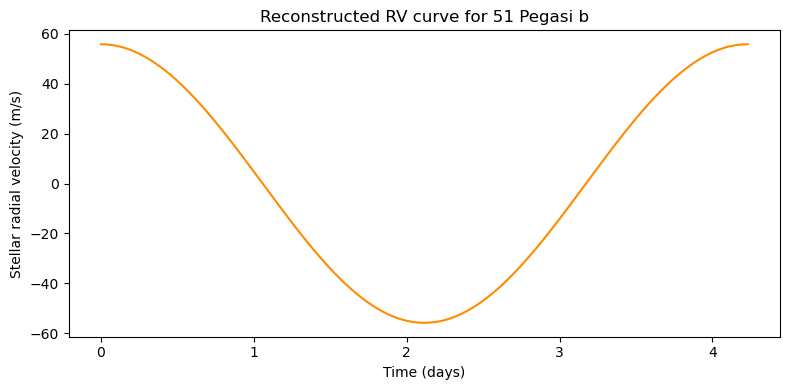

In [2]:
import matplotlib.pyplot as plt

period = tab['pl_orbper'][0]     # days
ecc = tab['pl_orbeccen'][0] if tab['pl_orbeccen'][0] else 0.0
K = tab['pl_rvamp'][0]           # m/s, radial velocity semi-amplitude
print(f'Orbital period: {period:.3f} days')
print(f'Eccentricity: {ecc:.3f}')
print(f'RV semi-amplitude K: {K:.2f} m/s')

# reconstruct a simple (near-circular, since ecc is tiny) RV curve over one orbit
t = np.linspace(0, period, 500)
phase = 2*np.pi*t/period
rv = K*np.cos(phase)

plt.figure(figsize=(8,4))
plt.plot(t, rv, color='darkorange')
plt.xlabel('Time (days)')
plt.ylabel('Stellar radial velocity (m/s)')
plt.title('Reconstructed RV curve for 51 Pegasi b')
plt.tight_layout()
plt.savefig('51peg_rv_curve.png', dpi=120)
plt.show()

The period is famously short -- about 4.2 days, meaning this planet orbits closer to its star than Mercury orbits the Sun, which is exactly why it was such a surprise discovery: nobody had expected a Jupiter-sized planet to exist in an orbit that tight. The RV amplitude of tens of meters per second is tiny (a brisk walking pace), which is a good reminder of how precise the spectroscopy behind this measurement had to be.

**What I'd look at next:** Pull the real published radial velocity data points from the discovery paper (rather than reconstructing an idealized curve from the fitted parameters) and overlay them on this model curve.

**Citation:** This research has made use of the NASA Exoplanet Archive, which is operated by the California Institute of Technology, under contract with NASA under the Exoplanet Exploration Program. See https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html.